# Proyecto 2 -- Data Mining sobre el Yelp Open Dataset

**Parte I: Preprocesamiento, limpieza, EDA y construccion de grafos.**

Se trabaja con una **muestra estratificada por ciudad** del Yelp Open Dataset (~3,000 negocios: cada ciudad aporta en proporcion a su peso en la poblacion, con semilla fija para reproducibilidad). Esta parte descarga el dataset via `kagglehub`, streamea los JSON crudos, limpia las cinco tablas (negocios, resenas, usuarios, check-ins y tips) y deja los parquet en `artifacts/`, de donde se alimentan las Partes II-VI.

In [0]:
# Descarga del Yelp Open Dataset (~4.35 GB) via kagglehub; queda cacheado en el
# driver. Credenciales: variables de entorno del cluster o secretos de Databricks.
import os

if not (os.environ.get('KAGGLE_USERNAME') and os.environ.get('KAGGLE_KEY')):
    os.environ['KAGGLE_USERNAME'] = dbutils.secrets.get(scope='proyecto-dm', key='kaggle_username')
    os.environ['KAGGLE_KEY'] = dbutils.secrets.get(scope='proyecto-dm', key='kaggle_key')

import importlib.util, subprocess, sys
if importlib.util.find_spec('kagglehub') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'kagglehub'])

import kagglehub
path = kagglehub.dataset_download('yelp-dataset/yelp-dataset')
print('Path to dataset files:', path)
print('Archivos:', sorted(os.listdir(path)))


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


100%|██████████| 4.07G/4.07G [01:31<00:00, 48.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/yelp-dataset/yelp-dataset/versions/4
Archivos: ['Dataset_User_Agreement.pdf', 'yelp_academic_dataset_business.json', 'yelp_academic_dataset_checkin.json', 'yelp_academic_dataset_review.json', 'yelp_academic_dataset_tip.json', 'yelp_academic_dataset_user.json']


In [0]:
%%writefile config.py

import os
import glob

# Alcance de los datos: todas las ciudades, muestreo estratificado por ciudad.
SCOPE = "sample"

# parametros del muestreo estratificado
SAMPLE_TARGET_BUSINESS = 3000   # tamano objetivo de la muestra de negocios
SAMPLE_SEED = 42                # semilla fija -> muestra reproducible

CITY_LABEL = "Yelp global (muestra estratificada por ciudad)"

def _kagglehub_root():
    """Ruta local del dataset descargado con kagglehub. Primero busca el cache
    en disco (no requiere red ni credenciales); solo si no existe llama a la
    API de Kaggle, para lo cual deben estar KAGGLE_USERNAME / KAGGLE_KEY
    (ver la celda de descarga del notebook de la Parte I)."""
    cache_base = os.environ.get(
        "KAGGLEHUB_CACHE", os.path.expanduser("~/.cache/kagglehub"))
    versions = os.path.join(
        cache_base, "datasets", "yelp-dataset", "yelp-dataset", "versions")
    if os.path.isdir(versions):
        found = sorted(glob.glob(os.path.join(versions, "*")))
        if found and glob.glob(os.path.join(found[-1], "*.json")):
            return found[-1]
    import kagglehub
    return kagglehub.dataset_download("yelp-dataset/yelp-dataset")


# dataset via kagglehub (cache local primero)
DATA_ROOT = _kagglehub_root()

def _find_raw(keyword):
    m = glob.glob(os.path.join(DATA_ROOT, f"**/*{keyword}*.json"), recursive=True)
    return m[0] if m else None

BUSINESS = _find_raw("business")
REVIEW   = _find_raw("review")
USER     = _find_raw("user")
CHECKIN  = _find_raw("checkin")
TIP      = _find_raw("tip")

def _locate_artifacts():
    # Carpeta 'artifacts' junto al notebook. Con DBR 14+ el cwd es la carpeta
    # del Workspace, asi que persiste entre reinicios del cluster y los
    # notebooks de las Partes II-VI la encuentran sin adjuntar nada.
    local = os.path.join(os.getcwd(), "artifacts")
    os.makedirs(local, exist_ok=True)
    return local

ARTIFACTS = _locate_artifacts()

MIN_USERS = 3000
MIN_LCC_FRACTION = 0.20
MIN_AVG_DEGREE = 1.0

Writing config.py


# PARTE 1

In [0]:
%%writefile preprocessing.py
import os
import json
import pandas as pd
import config

_BIZ_FIELDS = ['business_id', 'name', 'address', 'city', 'state', 'postal_code',
               'latitude', 'longitude', 'stars', 'review_count', 'is_open',
               'attributes', 'categories', 'hours']
_REV_FIELDS = ['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny',
               'cool', 'text', 'date']
_USER_FIELDS = ['user_id', 'name', 'review_count', 'yelping_since', 'useful',
                'funny', 'cool', 'fans', 'elite', 'average_stars']
_TIP_FIELDS = ['user_id', 'business_id', 'text', 'date', 'compliment_count']

P_BIZ      = os.path.join(config.ARTIFACTS, 'sample_business.parquet')
P_REVIEWS  = os.path.join(config.ARTIFACTS, 'sample_reviews.parquet')
P_USERS    = os.path.join(config.ARTIFACTS, 'sample_users.parquet')
P_CHECKINS = os.path.join(config.ARTIFACTS, 'sample_checkins.parquet')
P_TIPS     = os.path.join(config.ARTIFACTS, 'sample_tips.parquet')


def _stream(path):
    with open(path) as fh:
        for line in fh:
            yield json.loads(line)


def _stratified_sample(df):
    """Muestreo estratificado proporcional por (ciudad, estado): cada estrato
    aporta negocios segun su peso en la poblacion, con semilla fija. Las
    ciudades muy chicas pueden aportar 0 (asignacion proporcional pura)."""
    frac = min(1.0, config.SAMPLE_TARGET_BUSINESS / len(df))
    strata = (df['city'].fillna('').str.strip().str.title() + ' | '
              + df['state'].fillna(''))
    sample = (df.groupby(strata, group_keys=False)
                .apply(lambda g: g.sample(frac=frac,
                                          random_state=config.SAMPLE_SEED)))
    _sample_report(df, sample, strata)
    return sample.reset_index(drop=True)


def _sample_report(full, sample, strata):
    """Documenta la representatividad: proporciones por ciudad y medias de
    variables clave en poblacion vs muestra."""
    print(f'     Muestreo estratificado: {len(sample):,} de {len(full):,} negocios '
          f'({len(sample) / len(full):.1%}), semilla={config.SAMPLE_SEED}')
    print('     Representatividad -- top ciudades (poblacion vs muestra):')
    s_strata = strata.loc[sample.index]
    for ciudad, n in strata.value_counts().head(8).items():
        pf = n / len(full)
        ps = (s_strata == ciudad).mean()
        print(f'       {ciudad:<30s} {pf:6.2%} vs {ps:6.2%}')
    print('     Representatividad -- medias (poblacion vs muestra):')
    for col in ('stars', 'review_count', 'is_open'):
        print(f'       {col:<13s} {full[col].mean():8.2f} vs {sample[col].mean():8.2f}')


def _business():
    rows = [{k: o.get(k) for k in _BIZ_FIELDS} for o in _stream(config.BUSINESS)]
    df = pd.DataFrame(rows, columns=_BIZ_FIELDS)
    df = _stratified_sample(df)
    for col in ('attributes', 'hours'):
        df[col] = df[col].apply(
            lambda d: json.dumps(d, ensure_ascii=False) if d is not None else None)
    return df


def _reviews(biz_ids):
    rows, n = [], 0
    for o in _stream(config.REVIEW):
        if o.get('business_id') in biz_ids:
            rows.append({k: o.get(k) for k in _REV_FIELDS})
        n += 1
        if n % 1_000_000 == 0:
            print(f'     ...{n:,} resenas escaneadas')
    print(f'     resenas escaneadas en total: {n:,}')
    df = pd.DataFrame(rows, columns=_REV_FIELDS)
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    return df


def _users(user_ids):
    rows, n = [], 0
    for o in _stream(config.USER):
        n += 1
        uid = o.get('user_id')
        if uid not in user_ids:
            continue
        rec = {k: o.get(k) for k in _USER_FIELDS}
        raw = (o.get('friends') or '').strip()
        all_friends = [] if raw in ('', 'None') else [f.strip() for f in raw.split(',')]
        subset_friends = [f for f in all_friends if f in user_ids]
        rec['n_friends_total'] = len(all_friends)
        rec['n_friends_subset'] = len(subset_friends)
        rec['friends_subset'] = ','.join(subset_friends)
        rows.append(rec)
        if n % 1_000_000 == 0:
            print(f'     ...{n:,} usuarios escaneados')
    cols = _USER_FIELDS + ['n_friends_total', 'n_friends_subset', 'friends_subset']
    df = pd.DataFrame(rows, columns=cols)
    df['yelping_since'] = pd.to_datetime(df['yelping_since'], errors='coerce')
    return df


def _filter_by_business(path, biz_ids, fields):
    rows = []
    for o in _stream(path):
        if o.get('business_id') in biz_ids:
            rows.append({k: o.get(k) for k in fields})
    return pd.DataFrame(rows, columns=fields)


def build_subset(rebuild=False):
    print(f'Construyendo el subconjunto de {config.CITY_LABEL}'
          f'{"  (rebuild=True)" if rebuild else ""}\n')

    if not rebuild and os.path.exists(P_BIZ):
        biz = pd.read_parquet(P_BIZ)
        print(f'1/5  Negocios: cache ({len(biz):,})')
    else:
        print('1/5  Negocios...')
        biz = _business()
        biz.to_parquet(P_BIZ, index=False)
        print(f'     {len(biz):,} negocios -> {P_BIZ}')
    biz_ids = set(biz['business_id'])

    if not rebuild and os.path.exists(P_REVIEWS):
        rev = pd.read_parquet(P_REVIEWS)
        print(f'2/5  Resenas: cache ({len(rev):,})')
    else:
        print('2/5  Resenas (streaming review.json, ~2 min)...')
        rev = _reviews(biz_ids)
        rev.to_parquet(P_REVIEWS, index=False)
        print(f'     {len(rev):,} resenas -> {P_REVIEWS}')
    user_ids = set(rev['user_id'])

    if not rebuild and os.path.exists(P_USERS):
        usr = pd.read_parquet(P_USERS)
        print(f'3/5  Usuarios: cache ({len(usr):,})')
    else:
        print('3/5  Usuarios (streaming user.json)...')
        usr = _users(user_ids)
        usr.to_parquet(P_USERS, index=False)
        print(f'     {len(usr):,} usuarios -> {P_USERS}')

    if not rebuild and os.path.exists(P_CHECKINS):
        print('4/5  Check-ins: cache')
    else:
        print('4/5  Check-ins...')
        chk = _filter_by_business(config.CHECKIN, biz_ids, ['business_id', 'date'])
        chk.to_parquet(P_CHECKINS, index=False)
        print(f'     {len(chk):,} negocios con check-ins -> {P_CHECKINS}')

    if not rebuild and os.path.exists(P_TIPS):
        print('5/5  Tips: cache')
    else:
        print('5/5  Tips...')
        tips = _filter_by_business(config.TIP, biz_ids, _TIP_FIELDS)
        tips.to_parquet(P_TIPS, index=False)
        print(f'     {len(tips):,} tips -> {P_TIPS}')

    print(f'\nListo. Subconjunto ({config.CITY_LABEL}) en {config.ARTIFACTS}')
    return load_subset()


def load_subset():
    return {
        'business': pd.read_parquet(P_BIZ),
        'reviews':  pd.read_parquet(P_REVIEWS),
        'users':    pd.read_parquet(P_USERS),
        'checkins': pd.read_parquet(P_CHECKINS),
        'tips':     pd.read_parquet(P_TIPS),
    }


if __name__ == '__main__':
    build_subset()

Writing preprocessing.py


In [0]:
# load_mod lee los .py directo desde disco (evita el cache de imports del Workspace)
import sys, os, importlib.util

def load_mod(name):
    path = os.path.join(os.getcwd(), name + '.py')
    assert os.path.exists(path), f'No existe {path}: corre primero su celda %%writefile'
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

config = load_mod('config')
preprocessing = load_mod('preprocessing')

assert hasattr(preprocessing, 'load_subset'), 'El archivo se copio incompleto; revisa la Celda 1.'

data = preprocessing.build_subset()

print('\n--- shapes ---')
for k, df in data.items():
    print(f'{k:9s}: {df.shape}')
data['business'].head()

Construyendo el subconjunto de Yelp global (muestra estratificada por ciudad)

1/5  Negocios...
     Muestreo estratificado: 2,943 de 150,346 negocios (2.0%), semilla=42
     Representatividad -- top ciudades (poblacion vs muestra):
       Philadelphia | PA               9.69% vs  9.89%
       Tucson | AZ                     6.16% vs  6.29%
       Tampa | FL                      6.03% vs  6.15%
       Indianapolis | IN               5.02% vs  5.13%
       Nashville | TN                  4.64% vs  4.72%
       New Orleans | LA                4.13% vs  4.21%
       Reno | NV                       3.95% vs  4.01%
       Edmonton | AB                   3.36% vs  3.43%
     Representatividad -- medias (poblacion vs muestra):
       stars             3.60 vs     3.58
       review_count     44.87 vs    42.72
       is_open           0.80 vs     0.79
     2,943 negocios -> /Workspace/Users/camila.rodriguez@fitia.app/dm3/artifacts/sample_business.parquet
2/5  Resenas (streaming review.json, ~2

,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,kfW3-LmZlKrXq3RndVXxdg,Pho Ben City,1844 Old York Rd,Abington,PA,19001,40.136728,-75.114270,4.0,124,1,"{""RestaurantsDelivery"": ""False"", ""Caters"": ""Tr...","Diners, Asian Fusion, Thai, Noodles, Breakfast...","{""Monday"": ""0:0-0:0"", ""Tuesday"": ""11:0-21:0"", ..."
1,Q9FuyltF8hyy1eNGr-HD_A,King Kong Buffet,1495 Old York Rd,Abington,PA,19001,40.125177,-75.115768,3.0,26,0,"{""GoodForKids"": ""True"", ""Ambience"": ""{'romanti...","Restaurants, Food, Buffets","{""Monday"": ""11:0-22:0"", ""Tuesday"": ""11:0-22:0""..."
2,AIjauqmxDv33yPRvDO9LQA,Cardano Realtors,1021 Old York Rd,Abington,PA,19001,40.111704,-75.122749,2.5,10,0,"{""BusinessAcceptsCreditCards"": ""False"", ""ByApp...","Real Estate, Real Estate Agents, Real Estate S...","{""Monday"": ""9:0-17:0"", ""Tuesday"": ""9:0-17:0"", ..."
3,duaBfE0uvFBgKeeQnhXkWw,SharpShooter Pit and Grill,8135 Gravois St,Affton,MO,63123,38.560188,-90.301192,4.5,59,1,"{""Alcohol"": ""u'none'"", ""RestaurantsReservation...","Barbeque, Restaurants","{""Wednesday"": ""11:0-19:0"", ""Thursday"": ""11:0-1..."
4,fmlU1_s_2hAHHpXlCIXPVg,Decaro's,602 E 3rd St,Alton,IL,62002,38.890524,-90.176826,4.5,33,1,"{""RestaurantsReservations"": ""True"", ""GoodForKi...","Restaurants, Pizza, Italian","{""Monday"": ""10:0-21:0"", ""Tuesday"": ""10:0-21:0""..."


### Cleaning

In [0]:
%%writefile cleaning.py
import ast
import json
import pandas as pd
import config
import preprocessing


def _parse_categories(s):
    if not s or (isinstance(s, float) and pd.isna(s)):
        return []
    return [c.strip() for c in str(s).split(',') if c.strip()]


def _coerce_value(v):
    if v is None or isinstance(v, bool):
        return v
    s = str(v).strip()
    if s in ('None', ''):
        return None
    if s == 'True':
        return True
    if s == 'False':
        return False
    if s.startswith('{') and s.endswith('}'):
        try:
            return {k: _coerce_value(val) for k, val in ast.literal_eval(s).items()}
        except (ValueError, SyntaxError):
            return s
    if s.lstrip('-').isdigit():
        return int(s)
    return s


def _parse_attributes(s):
    if not s or (isinstance(s, float) and pd.isna(s)):
        return {}
    try:
        raw = json.loads(s)
    except (json.JSONDecodeError, TypeError):
        return {}
    return {k: _coerce_value(v) for k, v in raw.items()}


def _parse_hours_count(s):
    if not s or (isinstance(s, float) and pd.isna(s)):
        return 0
    try:
        return len(json.loads(s))
    except (json.JSONDecodeError, TypeError):
        return 0


def clean_business(biz):
    rep, df, n0 = {}, biz.copy(), len(biz)
    df = df.drop_duplicates('business_id')
    rep['business_id duplicados eliminados'] = n0 - len(df)

    df['categories_list'] = df['categories'].apply(_parse_categories)
    df['n_categories'] = df['categories_list'].apply(len)
    rep['negocios sin categoria'] = int((df['n_categories'] == 0).sum())

    df['attributes_clean'] = df['attributes'].apply(_parse_attributes)
    df['price_range'] = df['attributes_clean'].apply(
        lambda d: d.get('RestaurantsPriceRange2') if isinstance(d, dict) else None)
    rep['negocios sin atributos'] = int((df['attributes_clean'].apply(len) == 0).sum())
    rep['negocios sin price_range'] = int(df['price_range'].isna().sum())

    df['n_days_open'] = df['hours'].apply(_parse_hours_count)
    rep['negocios sin horario'] = int((df['n_days_open'] == 0).sum())

    thr = df['review_count'].quantile(0.99)
    df['rc_outlier'] = df['review_count'] > thr
    rep[f'outliers review_count (>p99={thr:.0f}), marcados no eliminados'] = int(df['rc_outlier'].sum())
    return df, rep


def clean_reviews(rev):
    rep, df, n0 = {}, rev.copy(), len(rev)
    df = df.drop_duplicates('review_id')
    rep['review_id duplicados eliminados'] = n0 - len(df)

    n1 = len(df)
    df = df.sort_values('date').drop_duplicates(['user_id', 'business_id'], keep='last')
    rep['pares (user,business) repetidos colapsados al mas reciente'] = n1 - len(df)

    df['stars'] = pd.to_numeric(df['stars'], errors='coerce')
    rep['reviews con stars invalido'] = int(df['stars'].isna().sum())

    df['text'] = df['text'].fillna('')
    df['text_len'] = df['text'].str.len()
    rep['reviews con texto vacio'] = int((df['text_len'] == 0).sum())
    return df, rep


def clean_users(usr):
    rep, df, n0 = {}, usr.copy(), len(usr)
    df = df.drop_duplicates('user_id')
    rep['user_id duplicados eliminados'] = n0 - len(df)

    elite = df['elite'].fillna('').astype(str)
    df['n_elite_years'] = elite.apply(
        lambda s: 0 if s.strip() in ('', 'None') else len([y for y in s.split(',') if y.strip()]))
    df['is_elite'] = df['n_elite_years'] > 0
    rep['usuarios elite'] = int(df['is_elite'].sum())

    thr = df['review_count'].quantile(0.99)
    df['rc_outlier'] = df['review_count'] > thr
    rep[f'outliers review_count (>p99={thr:.0f}), marcados no eliminados'] = int(df['rc_outlier'].sum())
    return df, rep


def clean_checkins(chk):
    df = chk.copy()
    df['n_checkins'] = df['date'].fillna('').apply(
        lambda s: 0 if not s else len(str(s).split(',')))
    return df, {'total check-ins contados': int(df['n_checkins'].sum())}


def clean_tips(tips):
    df, n0 = tips.copy(), len(tips)
    df = df.drop_duplicates()
    df['text'] = df['text'].fillna('')
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    return df, {'tips duplicados eliminados': n0 - len(df)}


def clean_subset(data=None):
    if data is None:
        data = preprocessing.load_subset()

    biz, r1 = clean_business(data['business'])
    rev, r2 = clean_reviews(data['reviews'])
    usr, r3 = clean_users(data['users'])
    chk, r4 = clean_checkins(data['checkins'])
    tip, r5 = clean_tips(data['tips'])

    print(f'REPORTE DE LIMPIEZA -- {config.CITY_LABEL}')
    for title, rep in [('Negocios', r1), ('Resenas', r2), ('Usuarios', r3),
                       ('Check-ins', r4), ('Tips', r5)]:
        print(f'\n[{title}]')
        for k, v in rep.items():
            print(f'  - {k}: {v:,}' if isinstance(v, int) else f'  - {k}: {v}')

    print('\nFilas tras limpieza:')
    for k, df in [('business', biz), ('reviews', rev), ('users', usr),
                  ('checkins', chk), ('tips', tip)]:
        print(f'  {k:9s}: {len(df):,}')

    return {'business': biz, 'reviews': rev, 'users': usr,
            'checkins': chk, 'tips': tip}

Writing cleaning.py


In [0]:
# load_mod lee los .py directo desde disco (evita el cache de imports del Workspace)
import sys, os, importlib.util

def load_mod(name):
    path = os.path.join(os.getcwd(), name + '.py')
    assert os.path.exists(path), f'No existe {path}: corre primero su celda %%writefile'
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

config        = load_mod('config')
preprocessing = load_mod('preprocessing')
cleaning      = load_mod('cleaning')

clean = cleaning.clean_subset()
clean['business'][['name', 'categories_list', 'price_range', 'n_days_open', 'rc_outlier']].head()

,name,categories_list,price_range,n_days_open,rc_outlier
0,Pho Ben City,"[Diners, Asian Fusion, Thai, Noodles, Breakfas...",2.0,6,False
1,King Kong Buffet,"[Restaurants, Food, Buffets]",2.0,7,False
2,Cardano Realtors,"[Real Estate, Real Estate Agents, Real Estate ...",NaN,5,False
3,SharpShooter Pit and Grill,"[Barbeque, Restaurants]",2.0,5,False
4,Decaro's,"[Restaurants, Pizza, Italian]",2.0,7,False


### EDA

In [0]:
%%writefile eda.py
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import config


def plot_rating_distribution(clean):
    rev = clean['reviews']
    counts = rev['stars'].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(counts.index, counts.values, width=0.6, color='#378ADD')
    ax.set_xlabel('Estrellas'); ax.set_ylabel('Nro de resenas')
    ax.set_title(f'Distribucion de ratings -- {config.CITY_LABEL}')
    for x, y in zip(counts.index, counts.values):
        ax.text(x, y, f'{y:,}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout(); plt.show()
    print(f'Rating promedio: {rev["stars"].mean():.2f} (sesgo a 4-5, tipico de Yelp)')


def plot_review_length(clean):
    rev = clean['reviews']
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(rev['text_len'].clip(upper=2000), bins=50, color='#1D9E75')
    ax.set_xlabel('Longitud de resena (caracteres, recortado a 2000)')
    ax.set_ylabel('Nro de resenas')
    ax.set_title('Distribucion de longitud de resenas')
    plt.tight_layout(); plt.show()
    print(f'Mediana de longitud: {rev["text_len"].median():.0f} caracteres')


def _loglog(series, ax, xlabel, color):
    vc = series.value_counts().sort_index()
    vc = vc[vc.index > 0]
    ax.scatter(vc.index, vc.values, s=12, color=color, alpha=0.6)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel(xlabel); ax.set_ylabel('Frecuencia (nro de elementos)')


def plot_powerlaws(clean):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    _loglog(clean['business']['review_count'], axes[0],
            'Resenas por negocio', '#D85A30')
    axes[0].set_title('Power-law: actividad de negocios')
    per_user = clean['reviews']['user_id'].value_counts()
    _loglog(per_user, axes[1], 'Resenas por usuario (en la muestra)', '#534AB7')
    axes[1].set_title('Power-law: actividad de usuarios')
    plt.tight_layout(); plt.show()
    print('Ambas siguen ley de potencias: pocos muy activos, larga cola de casuales.')


def plot_top_categories(clean, top=15):
    cats = Counter()
    for lst in clean['business']['categories_list']:
        cats.update(lst)
    common = pd.Series(dict(cats.most_common(top))).iloc[::-1]
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(common.index, common.values, color='#378ADD')
    ax.set_xlabel('Nro de negocios')
    ax.set_title(f'Top {top} categorias -- {config.CITY_LABEL}')
    plt.tight_layout(); plt.show()


def plot_geographic(clean):
    biz = clean['business']
    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(biz['longitude'], biz['latitude'], c=biz['stars'],
                    cmap='viridis', s=14, alpha=0.6)
    ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
    ax.set_title(f'Negocios de {config.CITY_LABEL} (color = estrellas)')
    fig.colorbar(sc, ax=ax, label='Estrellas')
    plt.tight_layout(); plt.show()


def plot_temporal(clean):
    rev = clean['reviews'].dropna(subset=['date'])
    monthly = rev.set_index('date').resample('MS').size()
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(monthly.index, monthly.values, color='#0F6E56')
    ax.set_xlabel('Fecha'); ax.set_ylabel('Resenas por mes')
    ax.set_title('Evolucion temporal de resenas')
    plt.tight_layout(); plt.show()


def plot_friendship_degree(clean):
    deg = clean['users']['n_friends_subset']
    fig, ax = plt.subplots(figsize=(6, 4))
    _loglog(deg[deg > 0], ax, 'Amigos dentro de la muestra (grado)', '#993556')
    ax.set_title('Distribucion de grados del grafo de amistad')
    plt.tight_layout(); plt.show()
    print(f'{(deg == 0).mean():.1%} de usuarios sin amigos en la muestra; '
          f'el resto forma el nucleo social de la Parte II.')


def plot_segments(clean):
    biz, usr = clean['business'], clean['users']
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    by_open = biz.groupby('is_open')['stars'].mean()
    axes[0].bar(['Cerrado', 'Abierto'],
                [by_open.get(0, np.nan), by_open.get(1, np.nan)],
                color=['#888780', '#1D9E75'])
    axes[0].set_ylabel('Estrellas promedio')
    axes[0].set_title('Rating: abierto vs cerrado')
    by_elite = usr.groupby('is_elite')['average_stars'].mean()
    axes[1].bar(['No elite', 'Elite'],
                [by_elite.get(False, np.nan), by_elite.get(True, np.nan)],
                color=['#888780', '#534AB7'])
    axes[1].set_ylabel('Estrellas promedio dadas')
    axes[1].set_title('Comportamiento: elite vs no elite')
    plt.tight_layout(); plt.show()


def plot_all(clean):
    plot_rating_distribution(clean)
    plot_review_length(clean)
    plot_powerlaws(clean)
    plot_top_categories(clean)
    plot_geographic(clean)
    plot_temporal(clean)
    plot_friendship_degree(clean)
    plot_segments(clean)

Writing eda.py


REPORTE DE LIMPIEZA -- Yelp global (muestra estratificada por ciudad)

[Negocios]
  - business_id duplicados eliminados: 0
  - negocios sin categoria: 4
  - negocios sin atributos: 288
  - negocios sin price_range: 1,274
  - negocios sin horario: 468
  - outliers review_count (>p99=452), marcados no eliminados: 30

[Resenas]
  - review_id duplicados eliminados: 0
  - pares (user,business) repetidos colapsados al mas reciente: 4,658
  - reviews con stars invalido: 0
  - reviews con texto vacio: 0

[Usuarios]
  - user_id duplicados eliminados: 0
  - usuarios elite: 17,027
  - outliers review_count (>p99=864), marcados no eliminados: 1,033

[Check-ins]
  - total check-ins contados: 266,406

[Tips]
  - tips duplicados eliminados: 1

Filas tras limpieza:
  business : 2,943
  reviews  : 125,744
  users    : 103,447
  checkins : 2,572
  tips     : 17,895


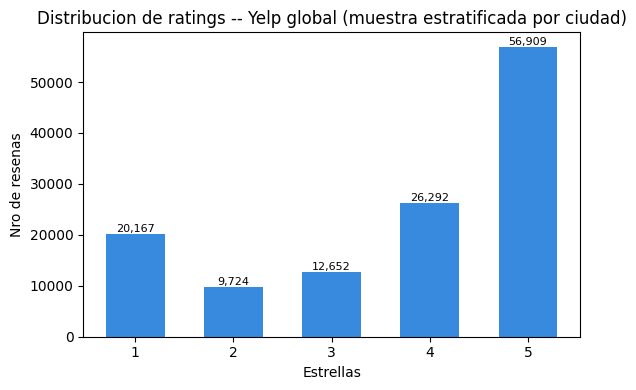

Rating promedio: 3.72 (sesgo a 4-5, tipico de Yelp)


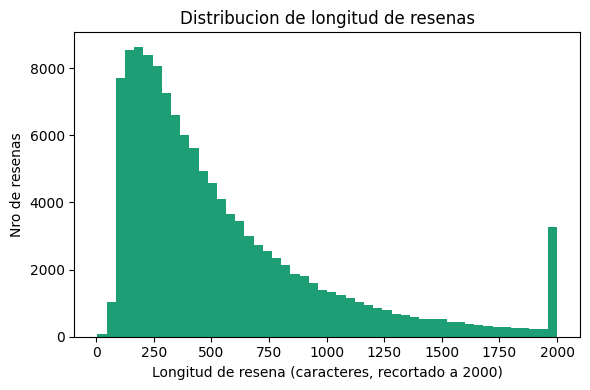

Mediana de longitud: 408 caracteres


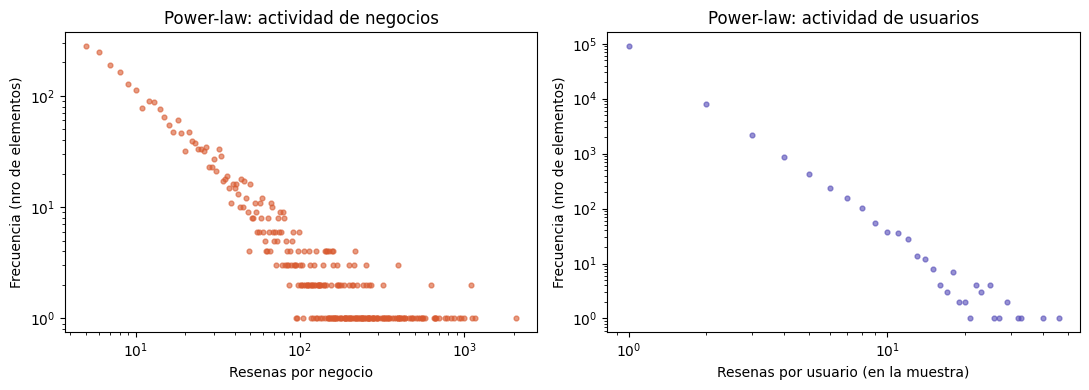

Ambas siguen ley de potencias: pocos muy activos, larga cola de casuales.


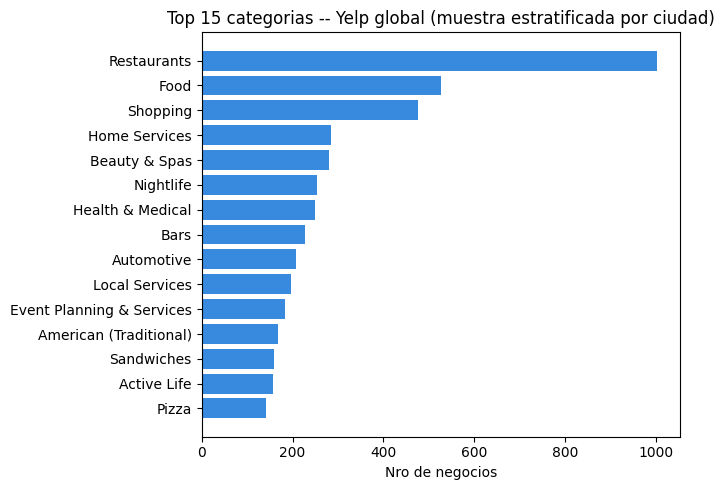

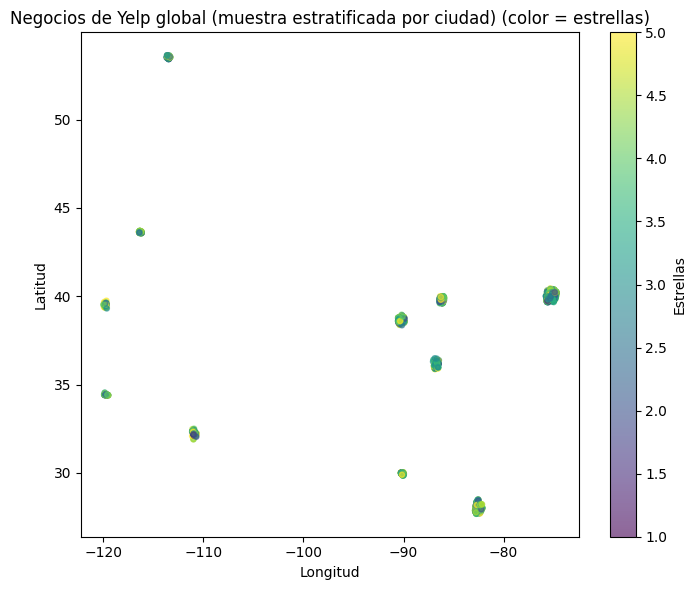

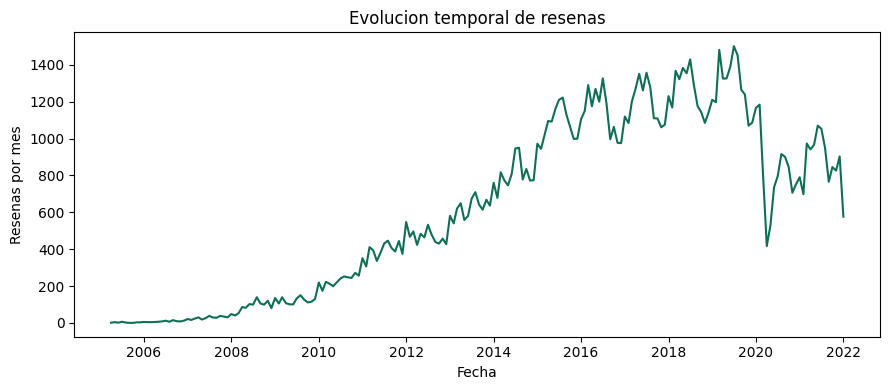

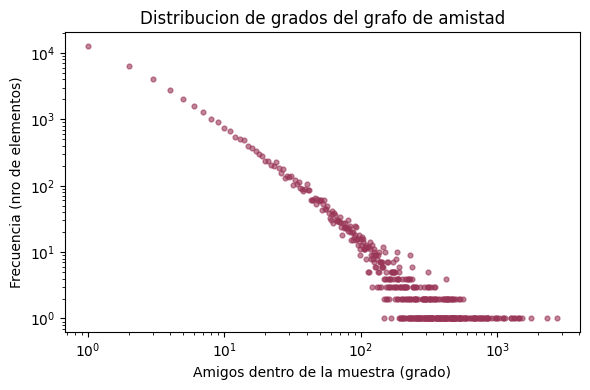

57.8% de usuarios sin amigos en la muestra; el resto forma el nucleo social de la Parte II.


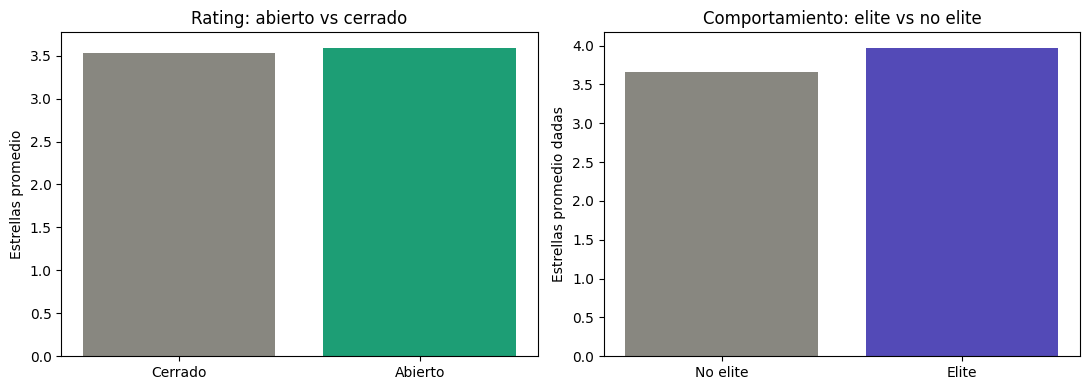

In [0]:
import sys, os, importlib.util
def load_mod(name):
    path = os.path.join(os.getcwd(), name + '.py')
    assert os.path.exists(path), f'No existe {path}: corre primero su celda %%writefile'
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod
config = load_mod('config')
preprocessing = load_mod('preprocessing')
cleaning = load_mod('cleaning')
eda = load_mod('eda')
clean = cleaning.clean_subset()
eda.plot_all(clean)

### Gráficos

In [0]:
%%writefile graphs.py
from collections import deque
import config


def build_bipartite(reviews):
    n_users = reviews['user_id'].nunique()
    n_biz = reviews['business_id'].nunique()
    n_edges = len(reviews)
    density = n_edges / (n_users * n_biz) if n_users and n_biz else 0
    return {'n_users': n_users, 'n_business': n_biz,
            'n_edges': n_edges, 'density': density}


def build_friendship(users):
    adj = {}
    for uid, fr in zip(users['user_id'], users['friends_subset']):
        adj.setdefault(uid, set())
        if isinstance(fr, str) and fr:
            for f in fr.split(','):
                if f:
                    adj[uid].add(f)
                    adj.setdefault(f, set()).add(uid)
    return adj


def _components(adj):
    seen, comps = set(), []
    for start in adj:
        if start in seen:
            continue
        comp, dq = [], deque([start])
        seen.add(start)
        while dq:
            u = dq.popleft()
            comp.append(u)
            for v in adj[u]:
                if v not in seen:
                    seen.add(v)
                    dq.append(v)
        comps.append(comp)
    return comps


def _bfs_farthest(adj, src):
    dist = {src: 0}
    dq = deque([src])
    far, fd = src, 0
    while dq:
        u = dq.popleft()
        for v in adj[u]:
            if v not in dist:
                dist[v] = dist[u] + 1
                if dist[v] > fd:
                    far, fd = v, dist[v]
                dq.append(v)
    return far, fd


def approx_diameter(adj, lcc_set):
    sub = {u: (adj[u] & lcc_set) for u in lcc_set}
    a, _ = _bfs_farthest(sub, next(iter(lcc_set)))
    _, d = _bfs_farthest(sub, a)
    return d


def friendship_metrics(users):
    adj = build_friendship(users)
    n = len(adj)
    deg_sum = sum(len(v) for v in adj.values())
    edges = deg_sum // 2
    density = deg_sum / (n * (n - 1)) if n > 1 else 0
    comps = _components(adj)
    lcc = max(comps, key=len) if comps else []
    diam = approx_diameter(adj, set(lcc)) if lcc else 0
    metrics = {'n_nodes': n, 'n_edges': edges, 'density': density,
               'n_components': len(comps), 'lcc_size': len(lcc),
               'lcc_fraction': len(lcc) / n if n else 0,
               'lcc_diameter_approx': diam}
    return metrics, adj, lcc


def build_graphs(clean=None):
    if clean is None:
        import cleaning
        clean = cleaning.clean_subset()

    bp = build_bipartite(clean['reviews'])
    fm, adj, lcc = friendship_metrics(clean['users'])

    print(f'GRAFOS INICIALES -- {config.CITY_LABEL}\n')
    print('[Bipartito usuario-negocio]')
    print(f"  usuarios:          {bp['n_users']:,}")
    print(f"  negocios:          {bp['n_business']:,}")
    print(f"  aristas (reseñas): {bp['n_edges']:,}")
    print(f"  densidad:          {bp['density']:.2e}")
    print('\n[Amistad usuario-usuario]')
    print(f"  nodos:             {fm['n_nodes']:,}")
    print(f"  aristas:           {fm['n_edges']:,}")
    print(f"  densidad:          {fm['density']:.2e}")
    print(f"  componentes:       {fm['n_components']:,}")
    print(f"  LCC:               {fm['lcc_size']:,} ({fm['lcc_fraction']:.1%})")
    print(f"  diametro aprox LCC: {fm['lcc_diameter_approx']}")

    return {'bipartite': bp, 'friendship': fm, 'friend_adj': adj, 'lcc': lcc}

Writing graphs.py


In [0]:
import sys, os, importlib.util
def load_mod(name):
    path = os.path.join(os.getcwd(), name + '.py')
    assert os.path.exists(path), f'No existe {path}: corre primero su celda %%writefile'
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod
config = load_mod('config')
preprocessing = load_mod('preprocessing')
cleaning = load_mod('cleaning')
graphs = load_mod('graphs')
clean = cleaning.clean_subset()
G = graphs.build_graphs(clean)

REPORTE DE LIMPIEZA -- Yelp global (muestra estratificada por ciudad)

[Negocios]
  - business_id duplicados eliminados: 0
  - negocios sin categoria: 4
  - negocios sin atributos: 288
  - negocios sin price_range: 1,274
  - negocios sin horario: 468
  - outliers review_count (>p99=452), marcados no eliminados: 30

[Resenas]
  - review_id duplicados eliminados: 0
  - pares (user,business) repetidos colapsados al mas reciente: 4,658
  - reviews con stars invalido: 0
  - reviews con texto vacio: 0

[Usuarios]
  - user_id duplicados eliminados: 0
  - usuarios elite: 17,027
  - outliers review_count (>p99=864), marcados no eliminados: 1,033

[Check-ins]
  - total check-ins contados: 266,406

[Tips]
  - tips duplicados eliminados: 1

Filas tras limpieza:
  business : 2,943
  reviews  : 125,744
  users    : 103,447
  checkins : 2,572
  tips     : 17,895
GRAFOS INICIALES -- Yelp global (muestra estratificada por ciudad)

[Bipartito usuario-negocio]
  usuarios:          103,449
  negocios:    

### Lectura de resultados de la Parte I

La muestra estratificada quedo en **2,943 negocios, 125,744 resenas y 103,447 usuarios** (2005-2022), con las proporciones por ciudad de la poblacion preservadas (Philadelphia, Tucson y Tampa encabezan, como en el dataset completo) y medias de stars/review_count/is_open practicamente identicas a las poblacionales, segun el reporte de representatividad.

De la limpieza destaca que los faltantes son **estructurales, no errores**: 43% de los negocios no declara price_range y 16% no publica horario; se imputan o marcan en vez de eliminarse. Los outliers de actividad (>p99) se marcan pero se conservan, porque en las Partes II y IV son justamente la senal (hubs, authorities, power-users).

Sobre los grafos: el bipartito usuario-negocio tiene densidad 4.1e-04 (cada usuario toca poquisimos negocios: mediana de 1 resena). El grafo de amistad tiene 305,776 aristas pero esta muy fragmentado: 58% de los usuarios no tiene ningun amigo dentro de la muestra y la componente gigante (LCC) cubre 41,832 usuarios (40.4%), con diametro aproximado 14. Las Partes II (ranking y comunidades) trabajan sobre ese LCC.